In [8]:
%matplotlib inline
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import set_config
from tempfile import TemporaryDirectory
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from scipy.stats import chi2_contingency
import scipy.stats as ss
import seaborn as sns
import numpy as np
import warnings

In [ ]:
ss = pd.read_csv("../../data/raw/sample_submission.csv")
target_column = ss.columns[-1]
target_column

'addicted_label'

In [ ]:
df_train = pd.read_csv("../../data/raw/train.csv")
df_train.pop(target_column)
df_test = pd.read_csv("../../data/raw/test.csv")

df_train['dataset'] = 'train'
df_test['dataset'] = 'test'

df = pd.concat([df_train, df_test], axis=0)
df["dataset"] = df["dataset"].astype('category')

df.reset_index(drop=True, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 987671 entries, 0 to 987670
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   id                       987671 non-null  int64   
 1   age                      941604 non-null  float64 
 2   daily_screen_time_hours  859029 non-null  float64 
 3   social_media_hours       806279 non-null  float64 
 4   gaming_hours             801430 non-null  float64 
 5   work_study_hours         908376 non-null  float64 
 6   sleep_hours              920736 non-null  float64 
 7   notifications_per_day    885866 non-null  float64 
 8   app_opens_per_day        881256 non-null  float64 
 9   weekend_screen_time      824911 non-null  float64 
 10  gender                   944425 non-null  str     
 11  stress_level             912897 non-null  str     
 12  academic_work_impact     917726 non-null  str     
 13  dataset                  987671 non-null  category
dtyp

In [11]:
target_column = "dataset"

Check dataset counts

<Axes: xlabel='dataset', ylabel='count'>

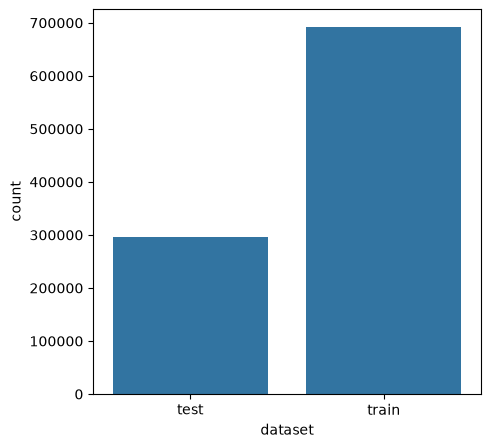

In [12]:
fig,axs = plt.subplots(figsize=(5,5),ncols=1)

sns.countplot(df,x=target_column,ax=axs)

Check categorical dataset correlations

In [13]:
cat_cols = df.select_dtypes(include="str").columns
cat_cols

Index(['gender', 'stress_level', 'academic_work_impact'], dtype='str')

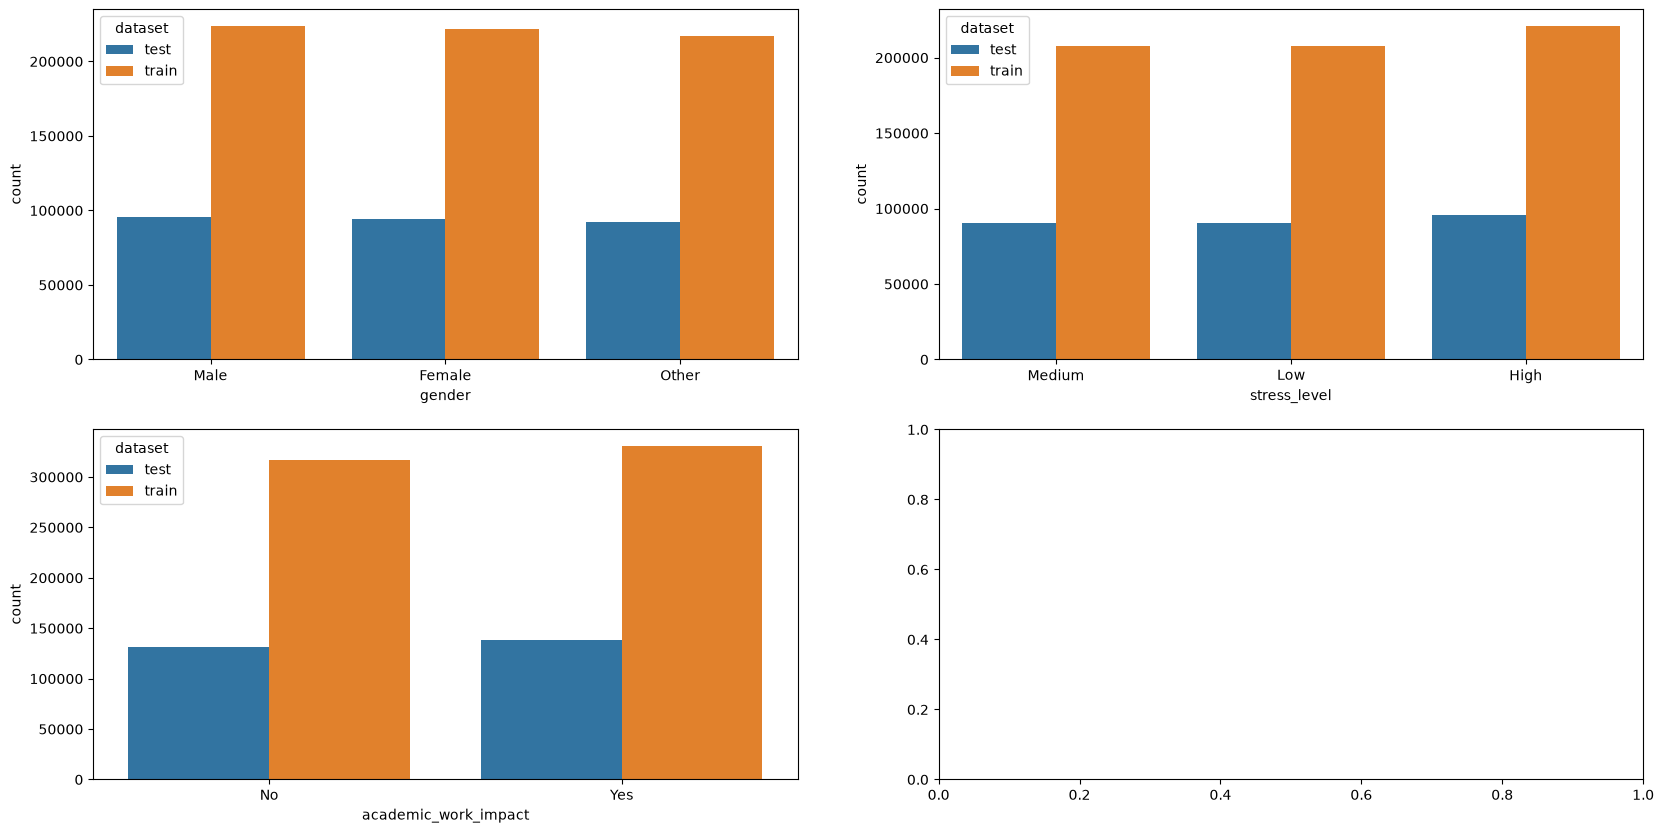

In [14]:
n_rows = (len(cat_cols)+1)//2
if n_rows > 0:
    fig,axs = plt.subplots(figsize=(20, n_rows*5), nrows=n_rows, ncols=2)

    for idx, cat_col in enumerate(cat_cols):
        sns.countplot(df, x=cat_col,hue=target_column,ax=axs[idx//2][idx%2])

Show numerical dataset correlations

In [15]:
num_cols = df.select_dtypes(include="float64").columns
num_cols

Index(['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time'],
      dtype='str')

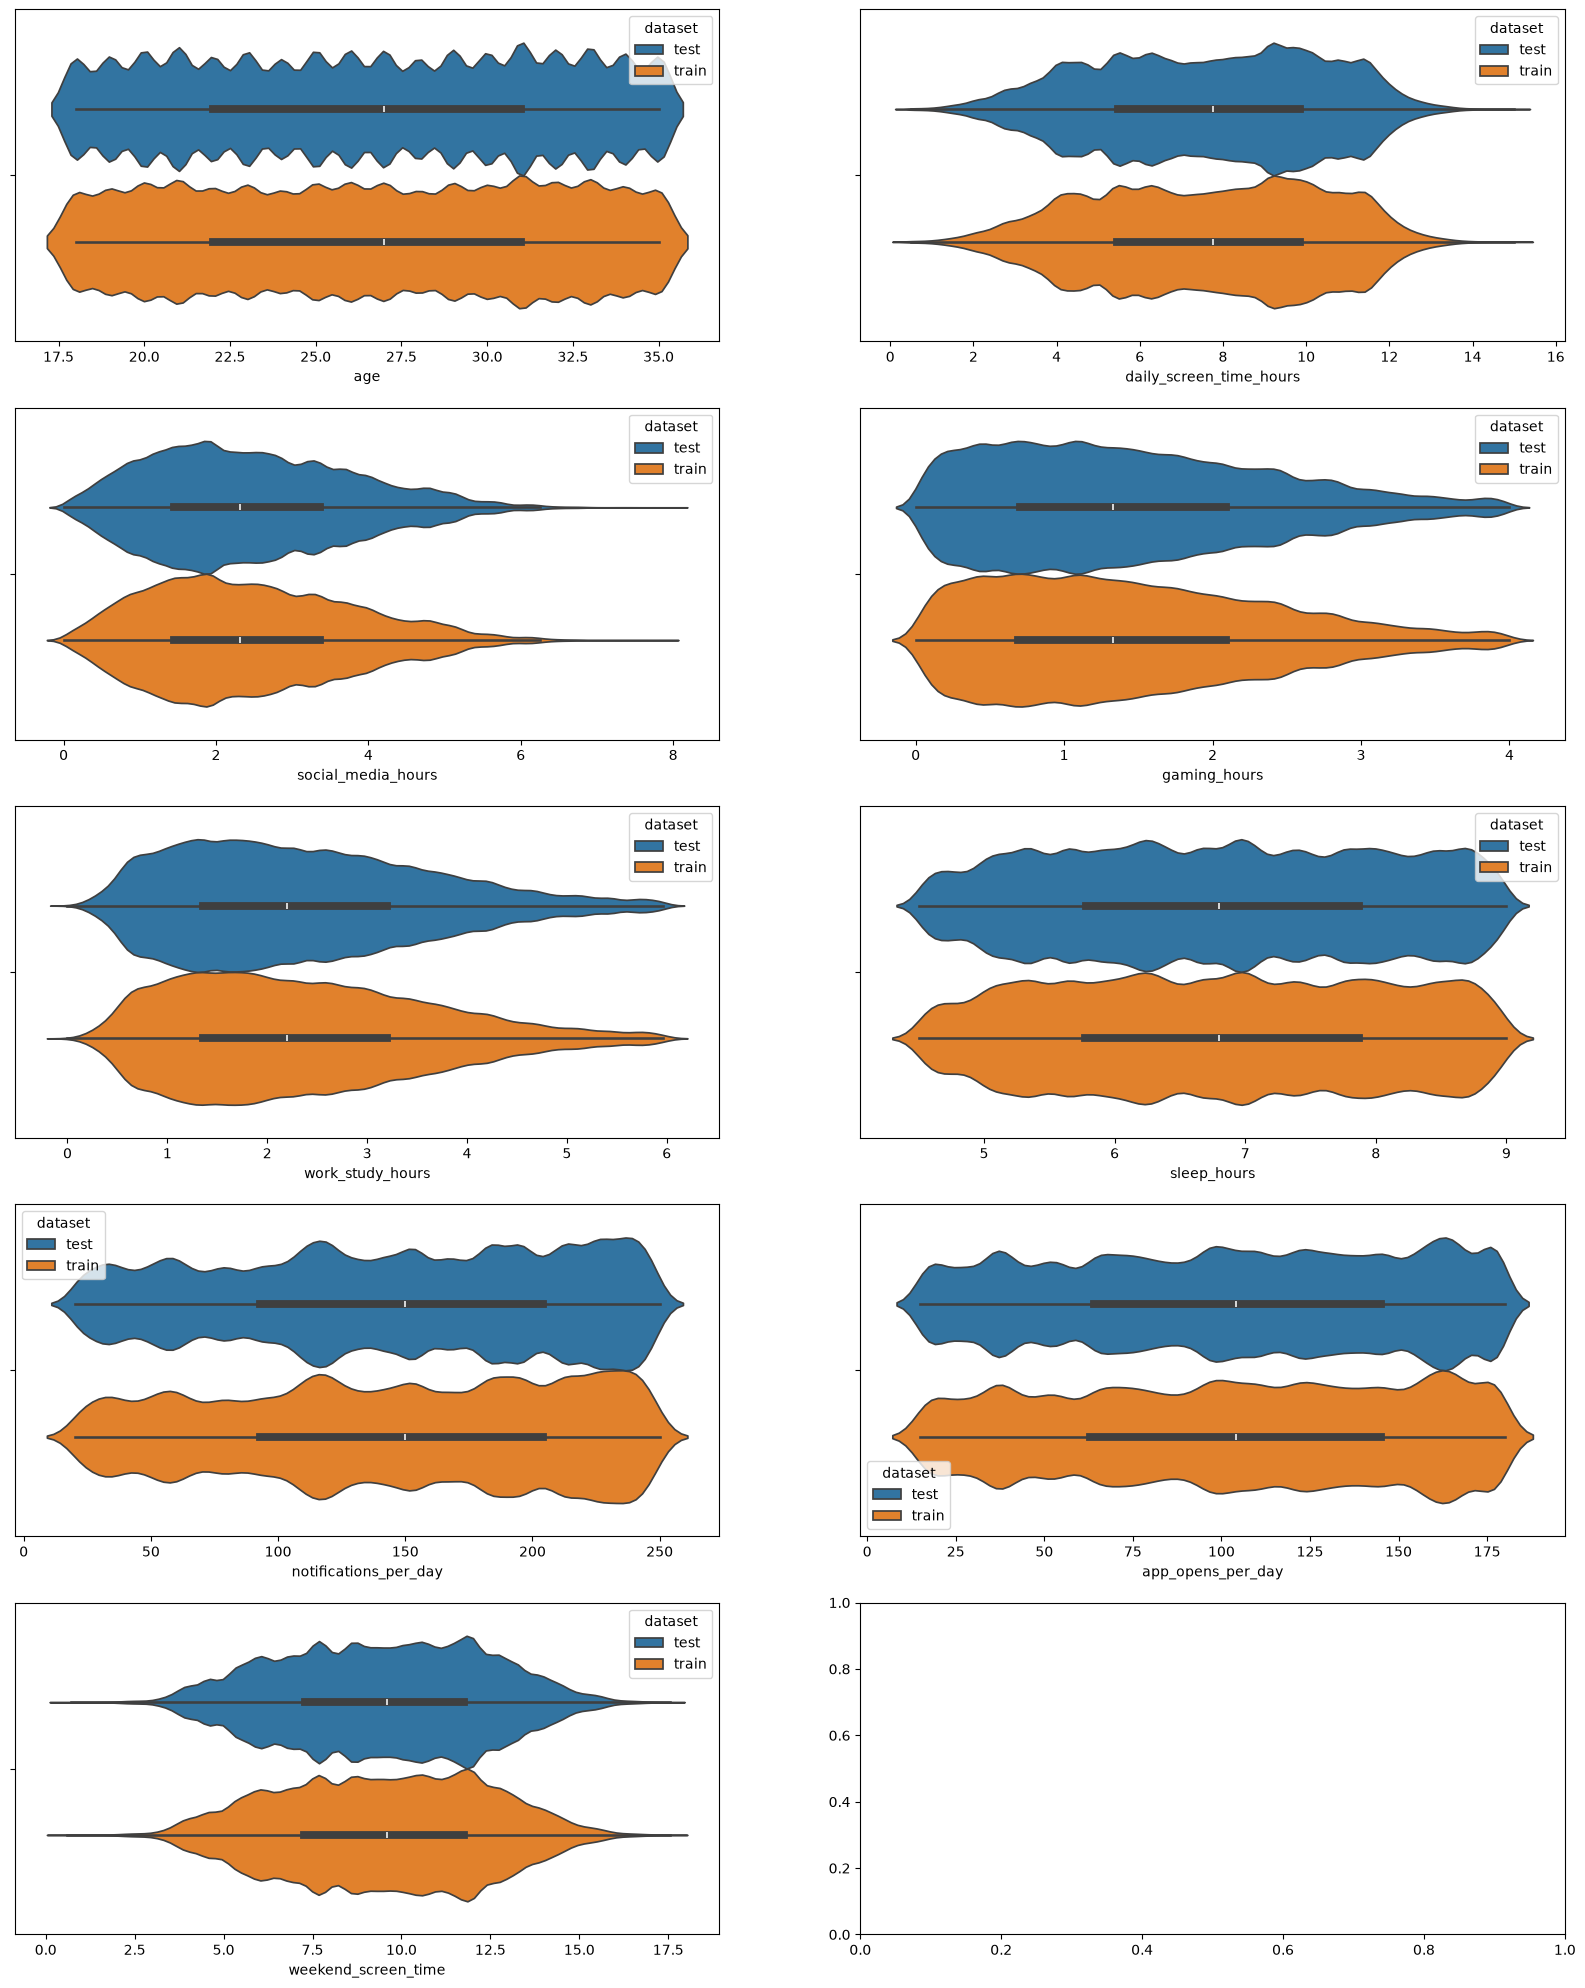

In [16]:
n_rows = (len(num_cols)+1)//2
if n_rows > 0:
    fig,axs = plt.subplots(figsize=(20, n_rows*5), nrows=n_rows, ncols=2)

    for idx, num_col in enumerate(num_cols):
        sns.violinplot(df, x=num_col,hue=target_column,ax=axs[idx//2][idx%2])

Show histograms of numerical features

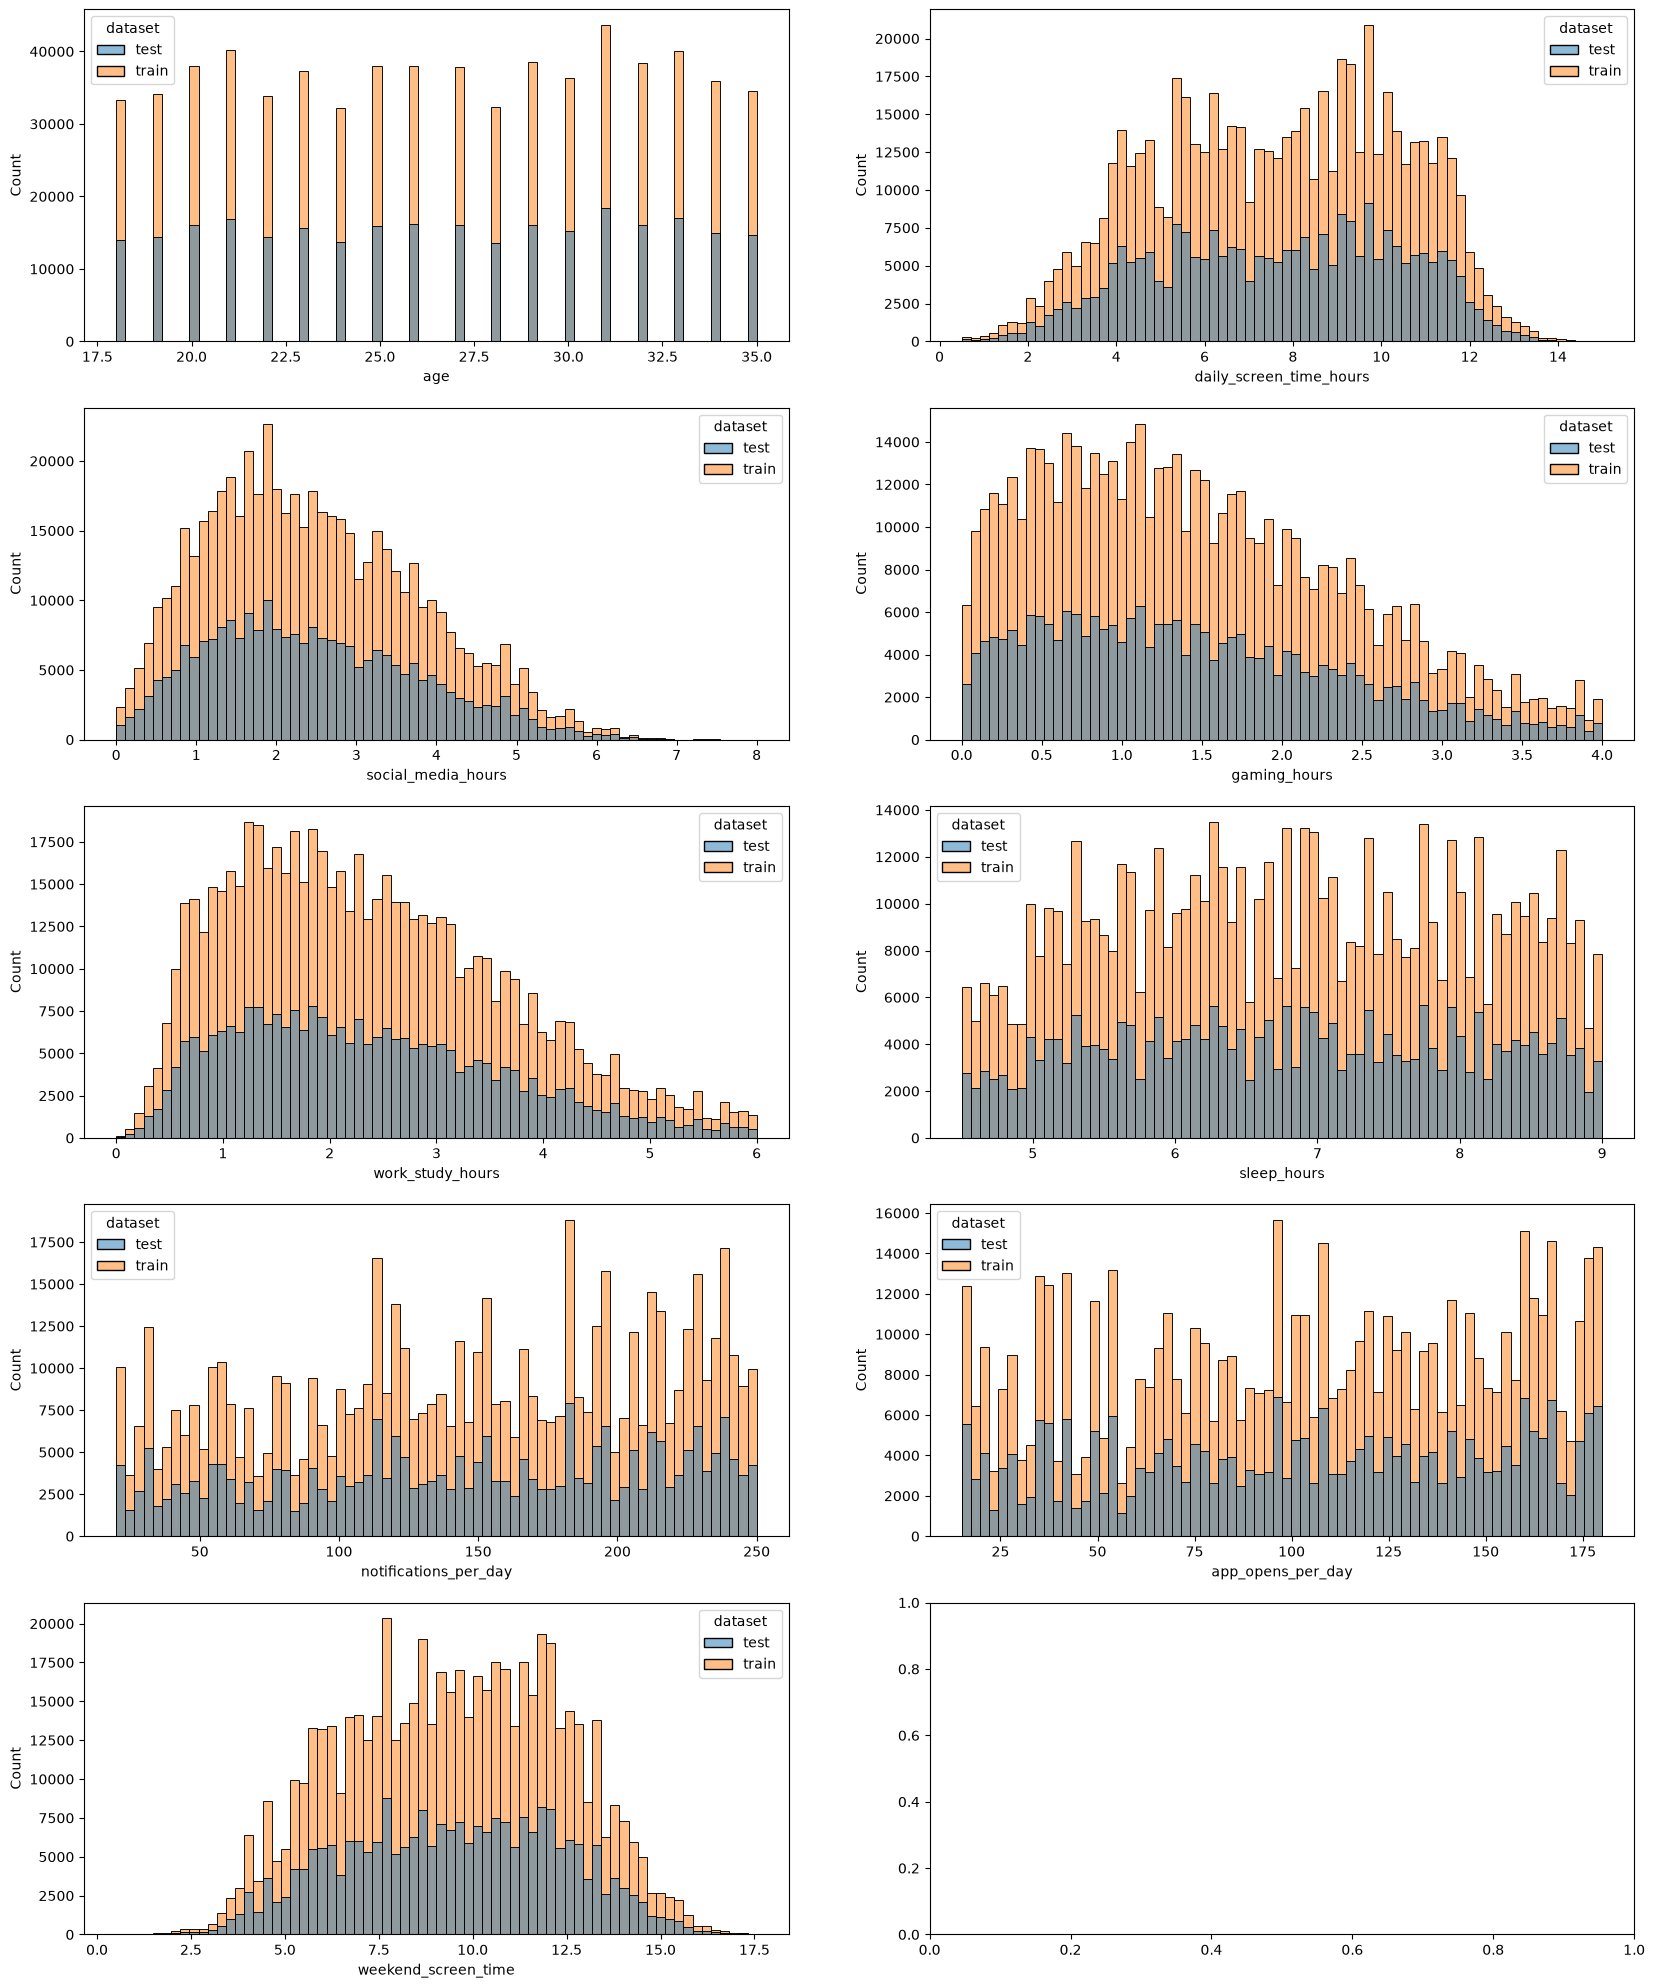

In [17]:
if n_rows > 0:
    fig,axs = plt.subplots(figsize=(20, n_rows*5), nrows=n_rows, ncols=2)

    for idx, num_col in enumerate(num_cols):
        sns.histplot(df, x=num_col,ax=axs[idx//2][idx%2],bins=70, hue=target_column)

**Check patterns across non-dataset numerical features**

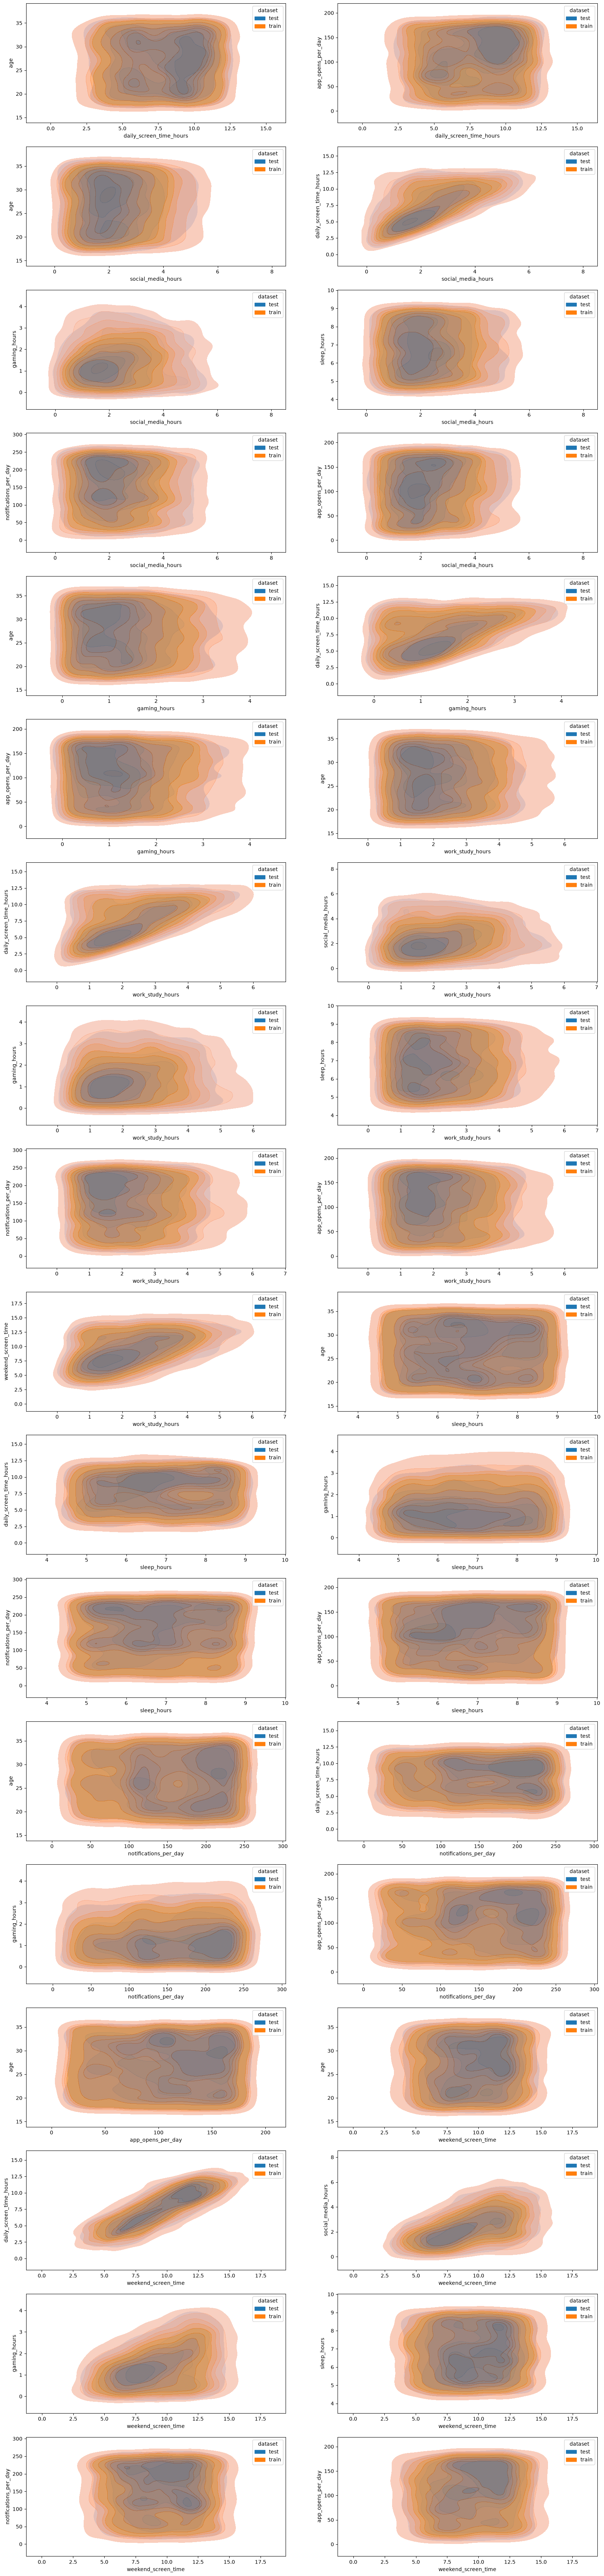

In [18]:
ddf = df.sample(n=10000, random_state=42) # Sample 10000 rows

n_rows = ((len(num_cols)*(len(num_cols)-1))//2+1)//2
if n_rows > 0:
    fig,axs = plt.subplots(figsize=(20, n_rows*5), nrows=n_rows, ncols=2)

    i = 0

    for r, c1 in enumerate(num_cols):
        for c, c2 in enumerate(num_cols):
            if c2 >= c1:
                continue
            sns.kdeplot(ddf, x=c1, y=c2, hue=target_column, ax=axs[i//2][i%2], fill=True, alpha=0.6, common_norm=True)
            i += 1

**Check patterns across numerical categorical features**

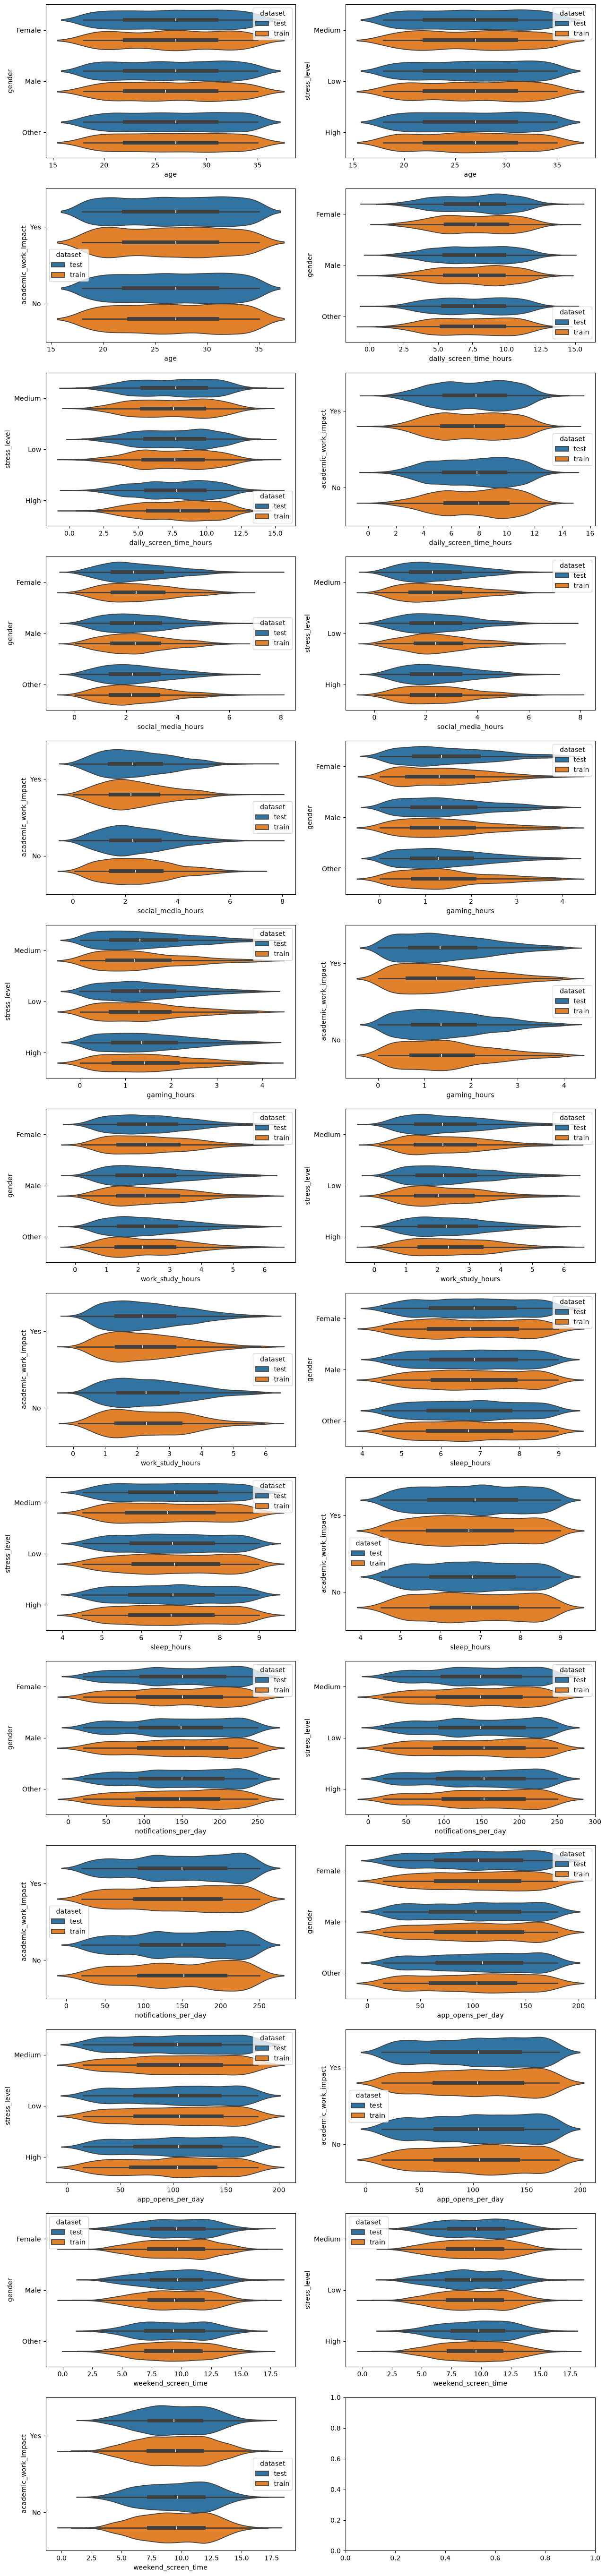

In [19]:
n_graphs = len(cat_cols) * len(num_cols)
n_rows = (n_graphs+1)//2

if n_rows > 0:
    fig, axs = plt.subplots(figsize=(15, n_rows*5),nrows=n_rows, ncols=2)

    i = 0

    for r, num_col in enumerate(num_cols):
        for c, cat_col in enumerate(cat_cols):
            sns.violinplot(ddf, x=num_col, y=cat_col, hue=target_column, ax=axs[i//2][i%2])
            i += 1